<a href="https://colab.research.google.com/github/shakirali/nebius/blob/main/tiny_transformer_lm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework: Build Your Own Tiny Transformer (Language Model)

In this assignment you will implement a **decoder-only Transformer** (GPT-style)
from scratch in PyTorch and train it on character-level
[Tiny Shakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt).

By the end, the model will generate text that at least *looks* Shakespearean
(correct-ish words, punctuation, line breaks with speaker names).

## What you will implement

You have already built RNN language models using `nn.LSTM` / `nn.GRU`. This time
you will build **all of the Transformer's core pieces yourself**:

1. **Multi-head causal self-attention** — the heart of the model.
2. **Position-wise feed-forward network**.
3. **Transformer block** — attention + FFN with residual connections and LayerNorm.
4. **Full LM** — token + positional embeddings, a stack of blocks, a final
   classifier head, and an autoregressive `generate` method.

Everything is marked with `# TODO` comments. The training loop, the data pipeline,
and the sanity checks are provided — you should not need to modify them.

## Recommended runtime

This notebook trains in **∼3–5 minutes on a Colab T4 GPU**. Make sure to
switch the runtime type to **GPU** (*Runtime → Change runtime type → T4 GPU*).
It will also run on CPU, just much more slowly.


## 1. Setup


In [2]:
import math
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Fixed seed so your loss curves are reproducible. Do not change this before
# submitting — we want everyone to see the same numbers.
torch.manual_seed(1337)

Using device: cpu


## 2. Data

We'll use **Tiny Shakespeare**, about 1.1 MB of concatenated plays. We work at
the **character level** so we don't need a tokenizer — our vocabulary is just
the set of unique characters in the file (~65 symbols).


In [3]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url, timeout=30).text
print(f"Loaded {len(text):,} characters")
print("--- first 250 characters ---")
print(text[:250])

Loaded 1,115,394 characters
--- first 250 characters ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [4]:
# Build the character-level vocabulary.
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s: str) -> list[int]:
    return [stoi[c] for c in s]

def decode(ids) -> str:
    return "".join(itos[int(i)] for i in ids)

print(f"Vocab size: {vocab_size}")
print("Vocabulary:", "".join(chars))
print("Encoded 'Hello':", encode("Hello"))
print("Decoded back: ", repr(decode(encode("Hello"))))

Vocab size: 65
Vocabulary: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
Encoded 'Hello': [20, 43, 50, 50, 53]
Decoded back:  'Hello'


In [5]:
# Encode the whole corpus as a single long tensor of token ids.
data = torch.tensor(encode(text), dtype=torch.long)

# 90 / 10 train / validation split (no shuffling — it's one long document).
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]
print(f"train: {len(train_data):,} tokens  val: {len(val_data):,} tokens")

train: 1,003,854 tokens  val: 111,540 tokens


## 3. Hyperparameters

These are sized to train in a few minutes on a Colab T4. You can make them
larger once everything works — especially `n_layer`, `n_embd`, and `max_iters` —
to get better samples. (You are *not* required to tune these for this assignment.)


In [6]:
# Model
block_size = 128   # max context length (how many tokens the model sees at once)
n_embd     = 192   # embedding / residual stream dimension
n_head     = 6     # number of attention heads (n_embd must be divisible by n_head)
n_layer    = 4     # number of Transformer blocks
dropout    = 0.1

# Training
batch_size      = 64
learning_rate   = 3e-4
max_iters       = 5000
eval_interval   = 500
eval_iters      = 200   # how many batches to average val loss over

In [7]:
def get_batch(split: str):
    """Sample a random batch of (x, y) pairs.

    For each of `batch_size` examples we pick a random start index `i` into the
    split and return:
        x = tokens[i : i + block_size]
        y = tokens[i + 1 : i + block_size + 1]   # x shifted by one position
    so that position `t` of `y` is the next-token target for position `t` of `x`.
    """
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i : i + block_size]         for i in ix])
    y = torch.stack([d[i + 1 : i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("xb:", xb.shape, xb.dtype)   # (batch_size, block_size)
print("yb:", yb.shape, yb.dtype)
print("\nFirst example in batch:")
print("  x:", repr(decode(xb[0].tolist())[:60]), "...")
print("  y:", repr(decode(yb[0].tolist())[:60]), "...")

xb: torch.Size([64, 128]) torch.int64
yb: torch.Size([64, 128]) torch.int64

First example in batch:
  x: ' if die, be brief,\nThat our swift-winged souls may catch the' ...
  y: 'if die, be brief,\nThat our swift-winged souls may catch the ' ...


## 4. Model components

Now the fun part. You will fill in four `nn.Module` classes:

1. `MultiHeadSelfAttention`
2. `FeedForward`
3. `Block`
4. `TinyTransformerLM`

A **sanity-check cell** at the end of this section runs a forward pass on random
input and checks the output shape and loss value — run it to catch bugs before
starting training.

**A few conventions used throughout:**

- `B` = batch size, `T` = sequence length (time), `C` = `n_embd` (channels).
- Inputs and outputs of every block are `(B, T, C)` — the "residual stream".
- We use **pre-norm** blocks: `x = x + sublayer(LayerNorm(x))`. This is what
  modern LLMs (GPT-2+, LLaMA, …) use; it trains more stably than the post-norm
  layout from the original *Attention Is All You Need* paper.


### 4.1 Multi-head causal self-attention

This is the single most important module — take your time with it.

**What it computes.** Given an input `x` of shape `(B, T, C)`:

1. Project `x` to **queries**, **keys**, and **values** (each `(B, T, C)`).
2. Split the channel dimension into `n_head` heads of size `head_size = C // n_head`,
   giving shapes `(B, n_head, T, head_size)`.
3. For each head, compute scaled dot-product attention:

   $$
   \text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}} + M\right) V
   $$

   where $M$ is a **causal mask** that sets entries above the diagonal to
   $-\infty$ — this prevents each position from attending to future positions.
4. Concatenate the heads back to `(B, T, C)` and apply a final linear projection.

**Hints.**

- Use **one** `nn.Linear(n_embd, 3 * n_embd)` to produce Q, K, V together — it's
  slightly faster than three separate linears. (Using three separate ones is
  also fine if you find it clearer.)
- Build the causal mask once in `__init__` with `torch.tril(torch.ones(block_size, block_size))`
  and register it with `self.register_buffer("mask", ...)`. Buffers move to the
  right device with `.to(device)` but are not trainable parameters.
- In `forward`, slice the mask to the *current* `T`: `self.mask[:T, :T]`. This
  matters during generation, where `T` can be less than `block_size`.
- `scores.masked_fill(mask == 0, float("-inf"))` is the idiomatic way to apply
  the mask before softmax.


In [ ]:
class MultiHeadSelfAttention(nn.Module):
    """Causal multi-head self-attention.

    Args:
        n_embd:     embedding / channel dimension (C).
        n_head:     number of attention heads. Must divide n_embd.
        block_size: maximum sequence length — used to size the causal mask.
        dropout:    dropout probability applied to attention weights and the
                    residual projection.
    """
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = n_head
        self.head_size = n_embd // n_head
        self.n_embd = n_embd

        # TODO 1a — Q/K/V projection.
        # Create a single linear layer that maps (B, T, n_embd) -> (B, T, 3*n_embd).
        # We'll split the output into q, k, v in forward().
        # Use bias=False (common convention; the bias would be redundant with the
        # layer norm that precedes this module).
        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)


        # TODO 1b — output projection.
        # Linear layer mapping (B, T, n_embd) -> (B, T, n_embd). Bias is fine here.
        self.out_proj = nn.Linear(n_embd, n_embd)

        # TODO 1c — causal mask.
        # Build a (block_size, block_size) lower-triangular matrix of 1s, and
        # register it as a non-parameter buffer named "mask".
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)))
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape

        # TODO 1d — compute q, k, v.
        # Apply self.qkv to x, then split the last dimension into three tensors
        # of shape (B, T, C) each.
        # Hint: torch.split or .chunk should help you.
        # q, k, v = ...
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        # TODO 1e — reshape each of q, k, v from (B, T, C) to (B, n_head, T, head_size).
        # Hint: use tensor.view
        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)


        # TODO 1f — scaled dot-product attention scores.
        # Compute scores of shape (B, n_head, T, T) where
        #   scores[b, h, i, j] = (q[b, h, i] · k[b, h, j]) / sqrt(head_size)
        scores = q @ k.transpose(-2, -1) / self.head_size ** 0.5

        # TODO 1g — apply the causal mask.
        # Set entries where self.mask[:T, :T] == 0 to float("-inf") so the
        # softmax gives them zero weight.
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float("-inf"))

        # TODO 1h — softmax over the last dimension to get attention weights,
        # then apply self.attn_dropout to them.
        att = F.softmax(scores, dim = -1)
        att = self.attn_dropout(att)

        # TODO 1i — weighted sum of values: (B, n_head, T, head_size).
        y = att @ v

        # TODO 1j — merge heads back to (B, T, C).
        # Hint: use transpose(), contiguous() and view()
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # TODO 1k — output projection + residual dropout, then return.
        return self.resid_dropout(self.out_proj(y))

#### ✅ Check yourself — attention

Run this cell after finishing TODO 1. It verifies two things:

1. **Output shape** matches input shape `(B, T, C)`.
2. **Causality**: perturbing the input at the *last* position must not change
   the outputs at earlier positions. If this fails, your causal mask is wrong
   or applied incorrectly (e.g. after softmax instead of before).


In [9]:
torch.manual_seed(0)

# Small module so the check runs instantly.
_mha = MultiHeadSelfAttention(n_embd=8, n_head=2, block_size=4, dropout=0.0).eval()
_x = torch.randn(2, 4, 8)

with torch.no_grad():
    _y = _mha(_x)

assert _y.shape == _x.shape, (
    f"Output shape {_y.shape} does not match input shape {_x.shape}. "
    f"Did you forget the output projection, or transpose heads back incorrectly?"
)

# Causality: perturb only the last position, check earlier outputs are unchanged.
_x2 = _x.clone()
_x2[:, -1, :] += torch.randn(8)
with torch.no_grad():
    _y2 = _mha(_x2)

_max_diff = (_y[:, :-1] - _y2[:, :-1]).abs().max().item()
assert _max_diff < 1e-6, (
    f"Causality violated — changing the last input position changed earlier "
    f"outputs by up to {_max_diff:.2e}. Check your causal mask: it should be "
    f"applied BEFORE the softmax and should set FUTURE positions to -inf."
)

# Also check the mask slicing works for T < block_size (important for generate()).
with torch.no_grad():
    _y_short = _mha(torch.randn(1, 2, 8))
assert _y_short.shape == (1, 2, 8), "Attention should handle T < block_size."

del _mha, _x, _x2, _y, _y2, _y_short
print("✅ Attention looks good: correct shape, causality preserved, variable-T OK")

✅ Attention looks good: correct shape, causality preserved, variable-T OK


### 4.2 Position-wise feed-forward network

A simple two-layer MLP applied **independently to each position**. In the original
paper the hidden dimension is `4 * n_embd`; we keep that convention. We use
**GELU** instead of ReLU, which is what GPT-2 and friends use.


In [10]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network: Linear -> GELU -> Linear -> Dropout."""
    def __init__(self, n_embd: int, dropout: float):
        super().__init__()
        # TODO 2 — build self.net as an nn.Sequential with four layers:
        #   1) Linear(n_embd, 4 * n_embd)
        #   2) GELU
        #   3) nn.Linear(4 * n_embd, n_embd)
        #   4) Dropout
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO 2 — return self.net(x)
        return self.net(x)

#### ✅ Check yourself — feed-forward

Verifies:

1. **Output shape** matches input shape.
2. **Position-wise independence**: applying the FFN to each position separately
   should give the same result as applying it to the full sequence. If this
   fails, you accidentally have a layer that mixes across positions.


In [11]:
torch.manual_seed(0)

_ffn = FeedForward(n_embd=16, dropout=0.0).eval()
_x = torch.randn(3, 7, 16)

with torch.no_grad():
    _y = _ffn(_x)

assert _y.shape == _x.shape, f"Expected {_x.shape}, got {_y.shape}"

# Position-wise check: per-position outputs should match whole-sequence outputs.
with torch.no_grad():
    _y_split = torch.cat([_ffn(_x[:, i:i+1, :]) for i in range(_x.shape[1])], dim=1)

_max_diff = (_y - _y_split).abs().max().item()
assert _max_diff < 1e-6, (
    f"FFN is not position-wise (diff={_max_diff:.2e}). It should only contain "
    f"nn.Linear / activation / Dropout — nothing that mixes across the T dim."
)

del _ffn, _x, _y, _y_split
print("✅ FeedForward looks good: correct shape, position-wise independence preserved")

✅ FeedForward looks good: correct shape, position-wise independence preserved


### 4.3 Transformer block

A pre-norm Transformer block:

```
x = x + attention(LayerNorm(x))
x = x + feedforward(LayerNorm(x))
```

The residual connections (`x + ...`) are what make very deep stacks trainable —
gradients flow directly through the additions.


In [12]:
class Block(nn.Module):
    """Pre-norm Transformer block."""
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        # TODO 3 — build the four submodules: LayerNorm, MultiHeadSelfAttention,
        # LayerNorm and FeedForward, passing parameters provided in __init__
        self.layerNormAttn = nn.LayerNorm(n_embd)
        self.mha = MultiHeadSelfAttention(
            n_embd=n_embd, 
            n_head=n_head, 
            block_size=block_size,
            dropout=dropout
        )
        self.layerNormFFN = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd=n_embd, dropout=dropout) 

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO 3 — implement the two pre-norm residual connections:
        x = x + self.mha(self.layerNormAttn(x))
        x = x + self.ffn(self.layerNormFFN(x))
        return x

#### ✅ Check yourself — block

Verifies the block preserves shape and **causality** end-to-end. Since the
FFN is position-wise, the whole block is causal iff your attention is causal —
so this check mostly confirms the residual + LayerNorm plumbing is correct.


In [13]:
torch.manual_seed(0)

_block = Block(n_embd=16, n_head=2, block_size=8, dropout=0.0).eval()
_x = torch.randn(2, 5, 16)

with torch.no_grad():
    _y = _block(_x)

assert _y.shape == _x.shape, f"Expected {_x.shape}, got {_y.shape}"

# End-to-end causality check through the block.
_x2 = _x.clone()
_x2[:, -1, :] += torch.randn(16)
with torch.no_grad():
    _y2 = _block(_x2)

_max_diff = (_y[:, :-1] - _y2[:, :-1]).abs().max().item()
assert _max_diff < 1e-6, (
    f"Block breaks causality (diff={_max_diff:.2e}). If your attention check "
    f"passed, the bug is likely in the residual wiring — make sure you do "
    f"`x = x + sublayer(LN(x))` and not `x = sublayer(LN(x))`."
)

del _block, _x, _x2, _y, _y2
print("✅ Block looks good: correct shape, causality preserved through residuals")

✅ Block looks good: correct shape, causality preserved through residuals


### 4.4 The full language model

Putting it together:

```
idx  (B, T)
  -> token_emb(idx)                   (B, T, C)
  +  pos_emb(0, 1, ..., T-1)          (   T, C)   # broadcast-added
  -> Block x n_layer                  (B, T, C)
  -> final LayerNorm                  (B, T, C)
  -> lm_head                          (B, T, vocab_size)   = logits
```

During training we also compute a cross-entropy loss against the shifted targets
`y`. During generation we sample one token at a time, append it to the context,
and repeat.

**Important for `generate`:** our positional embedding table only has
`block_size` entries, so if the running context gets longer than `block_size`
you **must** crop it to the last `block_size` tokens before each forward pass.


In [14]:
class TinyTransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        n_layer: int,
        block_size: int,
        dropout: float,
    ):
        super().__init__()
        self.block_size = block_size

        # TODO 4a — embeddings.
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)

        # TODO 4b — a stack of n_layer Blocks.
        # Hint: nn.Sequential(*[Block(...) for _ in range(n_layer)]) works,
        # or an nn.ModuleList if you prefer to iterate manually.
        self.blocks = nn.Sequential(
            *[Block(n_embd=n_embd, n_head=n_head, block_size=block_size, dropout=dropout) for _ in range(n_layer)]
        )

        # TODO 4c — final LayerNorm and the language modelling head.
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # (Optional) Better initialisation — slightly improves training stability.
        # You can leave this as is.
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets=None):
        B, T = idx.shape
        assert T <= self.block_size, (
            f"Sequence length {T} exceeds block_size {self.block_size}. "
            f"Did you forget to crop the context in generate()?"
        )

        # TODO 4d — compute token and positional embeddings and combine them.
        tok = self.token_emb(idx)  # (B, T, C)
        pos = self.pos_emb(torch.arange(T, device=idx.device))        # (T, C)
        x   = tok + pos        # (B, T, C)

        # TODO 4e — run through the stack of blocks, then the final LayerNorm,
        #           then the language modelling head to produce logits.
        x  = self.blocks(x)     # blocks
        x  = self.ln_f(x)     # LayerNorm
        logits  = self.lm_head(x)     # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # TODO 4f — compute cross-entropy loss.
            # F.cross_entropy expects logits of shape (N, vocab_size) and targets
            # of shape (N,). So you need to reshape logits_flat and targets_flat accordingly
            # Then: loss = F.cross_entropy(logits_flat, targets_flat)
            logits_flat = logits.view(B*T, vocab_size)
            targets_flat = targets.view(B*T,)
            loss = F.cross_entropy(logits_flat, targets_flat)
            
        # TODO 4g — return (logits, loss).
        return (logits, loss)

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Autoregressively extend `idx` by `max_new_tokens` tokens.

        idx: (B, T) tensor of starting context token ids.
        Returns: (B, T + max_new_tokens).
        """
        self.eval()
        for _ in range(max_new_tokens):
            # TODO 5a — crop the context to the last self.block_size tokens.
            idx_cond = idx[:, -self.block_size:]

            # TODO 5b — forward pass to get logits (pass targets=None).
            logits, _ = self.forward(idx_cond)

            # TODO 5c — keep only the logits at the last time step: shape (B, vocab_size).
            logits = logits[:, -1, :]

            # TODO 5d — convert to probabilities with softmax over the vocab dimension.
            probs = F.softmax(logits, -1)

            # TODO 5e — sample one token per batch element using torch.multinomial.
            # next_idx shape: (B, 1)
            next_idx = torch.multinomial(probs, 1)

            # TODO 5f — append the sampled token to idx along dim=1.
            idx = torch.cat((idx,next_idx), -1)
        return idx

### 4.5 Full-model sanity check

Instantiates a **small** model and verifies:

- **Forward pass**: `logits.shape == (batch_size, block_size, vocab_size)`
  and the initial loss is approximately `log(vocab_size)` (≈ 4.17 for 65 chars).
  An untrained model predicts roughly uniformly over the vocabulary, so the
  average cross-entropy in nats should be close to this value.
- **Generate**: produces the right number of new tokens, all tokens are
  in vocab range, the prefix context is preserved, and generation still works
  when the running context grows past `block_size` (the crop in TODO 5a).

If any of these fail, fix them before training — you'll just waste time
otherwise.


In [15]:
# --- Forward pass check ---
_test_model = TinyTransformerLM(
    vocab_size=vocab_size,
    n_embd=64, n_head=4, n_layer=2,
    block_size=block_size, dropout=0.0,
).to(device)

_xb, _yb = get_batch("train")
_logits, _loss = _test_model(_xb, _yb)

print("logits.shape:", tuple(_logits.shape))
print("loss:        ", f"{_loss.item():.4f}")
print("expected ~:  ", f"{math.log(vocab_size):.4f}")

assert _logits.shape == (batch_size, block_size, vocab_size), "Wrong logits shape!"
assert abs(_loss.item() - math.log(vocab_size)) < 0.5, (
    "Loss is suspiciously far from log(vocab_size). An untrained model should "
    "be nearly uniform — check your logits aren't being scaled strangely."
)

# --- Generate check ---
_ctx = torch.tensor([[0, 1, 2]], dtype=torch.long, device=device)
_out = _test_model.generate(_ctx, max_new_tokens=5)

assert _out.shape == (1, 3 + 5), f"Expected shape (1, 8), got {tuple(_out.shape)}"
assert (_out >= 0).all() and (_out < vocab_size).all(), "Generated tokens are outside the vocabulary!"
assert torch.equal(_out[:, :3], _ctx), "generate() must not modify the prefix context."

# Context longer than block_size must still work — tests the crop in TODO 5a.
_long_ctx = torch.zeros((1, block_size + 10), dtype=torch.long, device=device)
try:
    _test_model.generate(_long_ctx, max_new_tokens=3)
except AssertionError as e:
    raise AssertionError(
        "generate() failed with a context longer than block_size. "
        "Did you forget to crop idx to the last self.block_size tokens?"
    ) from e

del _test_model, _xb, _yb, _logits, _loss, _ctx, _out, _long_ctx
print("\n✅ Full-model sanity check passed (forward + generate)")

logits.shape: (64, 128, 65)
loss:         4.2016
expected ~:   4.1744

✅ Full-model sanity check passed (forward + generate)


## 5. Training

Nothing to implement here — just run the cells. Training should take a few
minutes on a GPU. You should see the train loss drop to roughly **1.4–1.6**
and the validation loss be only slightly higher.


In [16]:
@torch.no_grad()
def estimate_loss(model) -> dict[str, float]:
    """Average loss over `eval_iters` batches from each split."""
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [17]:
model = TinyTransformerLM(
    vocab_size=vocab_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    block_size=block_size,
    dropout=dropout,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params/1e6:.2f} M")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

Model parameters: 1.83 M


Now we'll train. After `max_iters = 5000` on a Colab T4, expected train loss should be around `1.4–1.5`, and validation loss around `1.5–1.7`. If your train loss doesn't go below `1.8`, there is almost surely a bug in the attention mask or the causal crop in `generate`.

In [18]:
history = {"iter": [], "train": [], "val": []}

for it in range(max_iters + 1):
    if it % eval_interval == 0 or it == max_iters:
        losses = estimate_loss(model)
        history["iter"].append(it)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        print(f"iter {it:5d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}")

    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

iter     0 | train loss 4.2057 | val loss 4.2059
iter   500 | train loss 1.9646 | val loss 2.0390
iter  1000 | train loss 1.5963 | val loss 1.7570
iter  1500 | train loss 1.4568 | val loss 1.6457
iter  2000 | train loss 1.3719 | val loss 1.5856
iter  2500 | train loss 1.3247 | val loss 1.5607
iter  3000 | train loss 1.2873 | val loss 1.5348
iter  3500 | train loss 1.2540 | val loss 1.5231
iter  4000 | train loss 1.2304 | val loss 1.5034
iter  4500 | train loss 1.2126 | val loss 1.4966
iter  5000 | train loss 1.1889 | val loss 1.5022


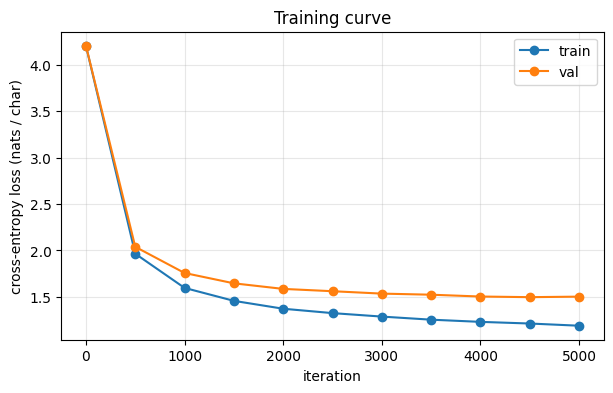

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(history["iter"], history["train"], label="train", marker="o")
plt.plot(history["iter"], history["val"],   label="val",   marker="o")
plt.xlabel("iteration")
plt.ylabel("cross-entropy loss (nats / char)")
plt.title("Training curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. How good is it? — perplexity

The loss curve shows the model is learning, but the raw number in nats is hard
to interpret. The standard LM metric is **perplexity**:

$$
\text{PPL} = \exp(\text{average cross-entropy loss})
$$

Intuition: perplexity is the **effective branching factor**. If a model has
perplexity `K` on held-out text, it is — on average — as confused as it would
be picking uniformly among `K` equally-likely options at each step. Lower is
better; `PPL = 1` means the model assigns probability 1 to the true next
character (perfect prediction).

We'll also report **bits per character** (bpc), which is what char-level LM
papers usually quote:

$$
\text{bpc} = \frac{\text{nll}}{\ln 2} = \log_2(\text{PPL})
$$

### Reference points for char-level Tiny Shakespeare

| Model                              | Val PPL   | Val bpc |
|------------------------------------|-----------|---------|
| Uniform random (untrained)         | 65 (= vocab size) | ≈ 6.02  |
| This notebook, default hyperparams | ≈ 4 – 5   | ≈ 2.0 – 2.3 |
| State-of-the-art char LM           | ≈ 2.5     | ≈ 1.3   |

The gap between "uniform" and your trained number is what training bought you.


In [20]:
final_losses = estimate_loss(model)

train_nll, val_nll = final_losses["train"], final_losses["val"]
train_ppl, val_ppl = math.exp(train_nll), math.exp(val_nll)
val_bpc = val_nll / math.log(2)

baseline_nll = math.log(vocab_size)
baseline_ppl = vocab_size
baseline_bpc = baseline_nll / math.log(2)

print(f"{'':22s} {'nll (nats)':>12s} {'perplexity':>12s} {'bpc':>8s}")
print(f"{'Uniform baseline':22s} {baseline_nll:12.4f} {baseline_ppl:12.2f} {baseline_bpc:8.2f}")
print(f"{'Train (your model)':22s} {train_nll:12.4f} {train_ppl:12.2f} {train_nll / math.log(2):8.2f}")
print(f"{'Val   (your model)':22s} {val_nll:12.4f} {val_ppl:12.2f} {val_bpc:8.2f}")

print(f"\n→ Your model is {baseline_ppl / val_ppl:.1f}× better than a uniform guesser "
      f"at predicting the next character.")

                         nll (nats)   perplexity      bpc
Uniform baseline             4.1744        65.00     6.02
Train (your model)           1.1846         3.27     1.71
Val   (your model)           1.4934         4.45     2.15

→ Your model is 14.6× better than a uniform guesser at predicting the next character.


## 7. Generate samples

If everything is implemented correctly, the output below should look like
(very strange, but recognisable) Shakespearean dialogue: speaker names in caps
followed by colons, a reasonable mix of words and punctuation, line breaks in
sensible places. It **will not** produce coherent sentences — the model is tiny
and trained for only a few thousand steps.

You can re-run this cell multiple times to get different samples (each
`torch.multinomial` call is random).


In [ ]:
# Seed the generator with a single token. In our sorted char vocabulary
# token 0 is the newline character, which is a natural place to start a
# Shakespeare sample (most lines begin with a speaker name after a newline).
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=500)[0].tolist()
print(decode(generated))



LUCENTIO:
I'll away not.

hair Peter;
The norther lurking now they have been feel'd
Your honour and altogether lamp. Pieet o'er farewell;
Are you king'd for after self-blabed,
But King Romeo could non man overward.

CLAUDIO:
I hear to be your honour.

ISABELLA:
I am deceived, in a pecta of woe,
Come in Lodon with they kings all in oEngland.

DUCHESS OF YORK:
Stop babe slaughter keeps them here as he is
As seem serve, whom here should her head waken their body
Upon his time to be how there and d


## Submission

Submit this notebook with **all cells executed** (so we can see your training
curve and generated samples). Make sure:

- All `raise NotImplementedError` lines are gone.
- The sanity-check cell passes.
- The final train loss is **below 1.8** and the generated sample is mostly
  made of real-looking English words.

Good luck!
